In [84]:
%load_ext autoreload
%autoreload 2

import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import jax

jax.config.update('jax_platforms', 'cpu')

plt.rcParams['font.family'] = 'Helvetica Light'

from behavioral_plotting import (
    plot_session,
    load_odor_site_df,
    plot_patch_statistics_by_session,
    plot_patch_statistics,
    plot_multi_df_accuracy_heatmap,
    plot_leave_probabilities,
    append_index_phase,
    plot_grouped_mean_std,
    plot_stop_fraction,
    odor_colors,
)
from aux_funcs import format_plot
from nb_analysis_tools import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
# had to clear the font cache to get the Helvetica Light font to work.
# If you see a warning about missing fonts, run this cell and restart the kernel.

# import matplotlib as mpl
# import shutil, os

# # Find and delete the font cache
# cache_dir = mpl.get_cachedir()
# print(f"Cache dir: {cache_dir}")

# # Delete cache files
# for f in os.listdir(cache_dir):
#     if f.endswith('.json') or f.endswith('.cache'):
#         os.remove(os.path.join(cache_dir, f))
#         print(f"Deleted: {f}")

# print("Done — restart the kernel now")

In [81]:
FIXED_EXP_GRU_REWARD_DECAY_NETWORKS = [
    '../../../results/fixed_exp_gru_reward_decay_net0/trajectories_20260409_181731.pkl',
    '../../../results/fixed_exp_gru_reward_decay_net1/trajectories_20260409_185208.pkl',
    '../../../results/fixed_exp_gru_reward_decay_net2/trajectories_20260409_192646.pkl',
    '../../../results/fixed_exp_gru_reward_decay_net3/trajectories_20260409_200130.pkl',
    '../../../results/fixed_exp_gru_reward_decay_net4/trajectories_20260409_203615.pkl',
]

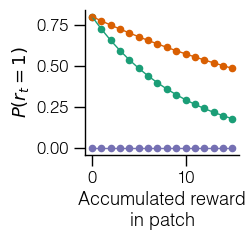

In [82]:
# ── Exponential decay curves ──────────────────────────────────────────────
prefactors  = [0,  0.8,  0.8]   # one per curve
decay_rates = [1,  1/10,  1/30]   # one per curve

x = np.arange(16)   # 0 through 20

fig, ax = plt.subplots(figsize=(2.5, 2.5))
for prefactor, decay_rate, color in zip(prefactors, decay_rates, odor_colors):
    y = prefactor * np.exp(-decay_rate * x)
    ax.plot(x, y, color=color, lw=1)
    ax.scatter(x, y, color=color, s=20)
ax.set_xlabel('Accumulated reward\nin patch')
ax.set_ylabel(r'$P(r_t=1)$')
format_plot(ax)
plt.tight_layout()
plt.show()


0.0
5.0
14.0
4.0
0.0
12.0
0.0
15.0
0.0
12.0
4.0
11.0
6.0
5.0
0.0
0.0
0.0
0.0
4.0
0.0
0.0
0.0
5.0
0.0
3.0
0.0
14.0
14.0
5.0
6.0
0.0
0.0
0.0
13.0
12.0
0.0
6.0
5.0
11.0
5.0
0.0
16.0
0.0
12.0
0.0
0.0
5.0
4.0
0.0
4.0
0.0
4.0
0.0
0.0
5.0
0.0
12.0
0.0
0.0
10.0
5.0
4.0
6.0
0.0
12.0
0.0
5.0
0.0
14.0
8.0
0.0
0.0
0.0
0.0
13.0
0.0
6.0
12.0
5.0
3.0
11.0
4.0
14.0
0.0
15.0
6.0
15.0
0.0


KeyboardInterrupt: 

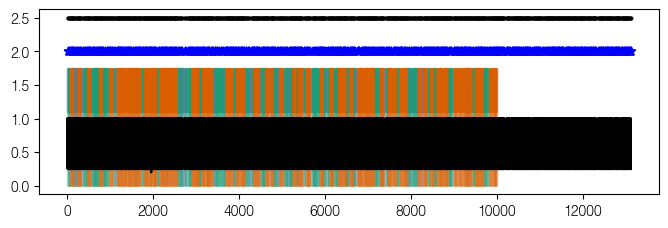

In [83]:
for i, data_path in enumerate(FIXED_EXP_GRU_REWARD_DECAY_NETWORKS):
    plot_session(data_path, session_idx=1, xlim=(0, 200), max_reward_param=40, max_reward_sites=30, use_fixed_colors=True, save_dir=f'../../../figures/gru_fixed_exp_decay_net_{i}')

In [8]:
dfs = [
    load_odor_site_df(x, nn_num=nn_num)
    for nn_num, x in enumerate(FIXED_EXP_GRU_REWARD_DECAY_NETWORKS)
]

Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated


<string>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



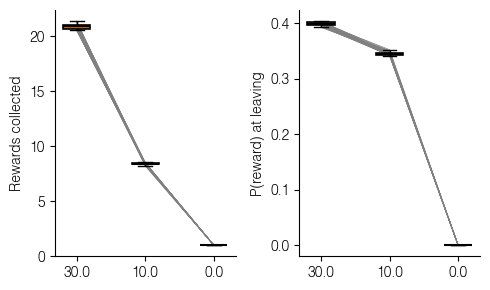

<string>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



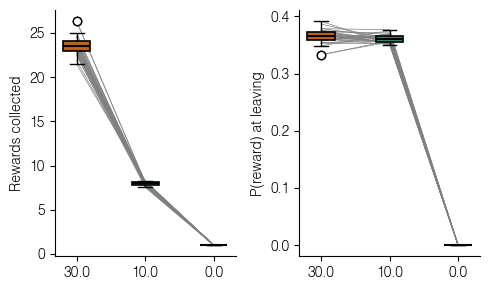

<string>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



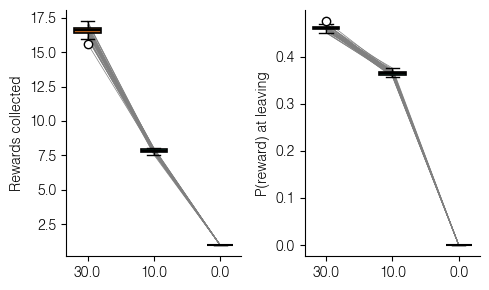

<string>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



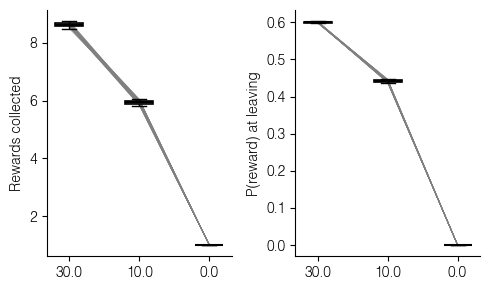

<string>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



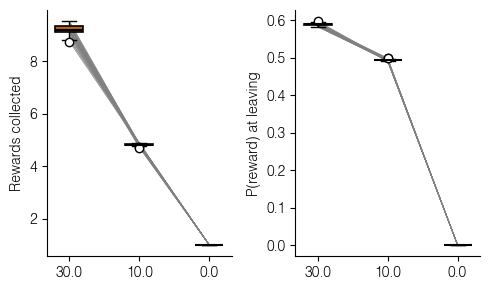

In [87]:
for df in dfs:
    plot_patch_statistics_by_session(df,fixed_colors=True)

In [ ]:
# fig = plot_patch_statistics(pd.concat(dfs))
# savefig(fig, '../../figures/fixed_networks_mvp_plots')

Processing GRU...
Processing GRU...
Processing GRU...
Processing GRU...
Processing GRU...


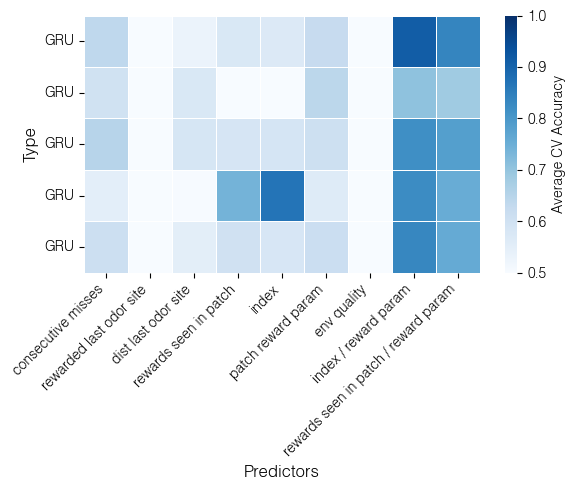

In [28]:
plot_multi_df_accuracy_heatmap(
    [df[df['index'] > 0] for df in dfs],
    [
        'consecutive_misses',
        'rewarded_last_odor_site',
        'dist_last_odor_site',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_param',
        'env_quality',
        'index / reward_param',
        'rewards_seen_in_patch / reward_param',
    ],
    df_labels=['GRU'] * len(dfs),
    figsize=(6, 5),
)

<string>:25: UserWarning: The figure layout has changed to tight


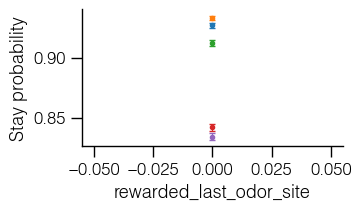

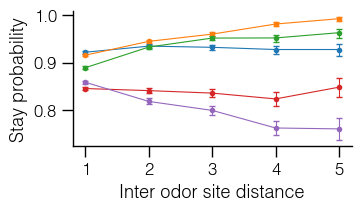

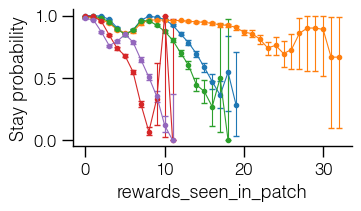

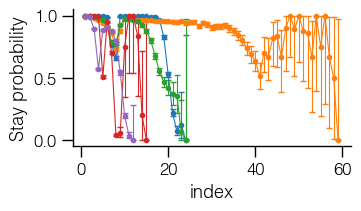

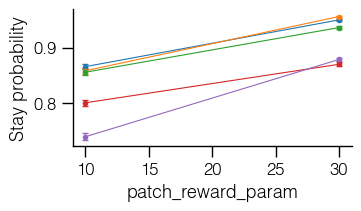

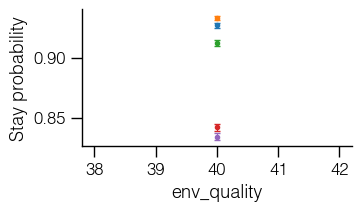

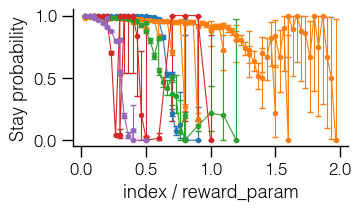

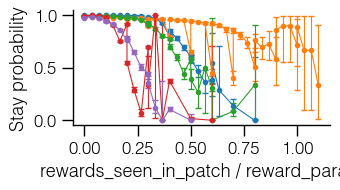

In [40]:
plot_leave_probabilities(
    [df[df['index'] > 0] for df in dfs],
    [
        'rewarded_last_odor_site',
        'dist_last_odor_site',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_param',
        'env_quality',
        'index / reward_param',
        'rewards_seen_in_patch / reward_param',
    ],
    x_labels=[
        'rewarded_last_odor_site',
        'Inter odor site distance',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_param',
        'env_quality',
        'index / reward_param',
        'rewards_seen_in_patch / reward_param',
    ],
)

In [ ]:
fig = plot_grouped_mean_std(
    append_index_phase(pd.concat([df[df['index'] > 0] for df in dfs])),
    'dist_last_odor_site',
    'segment',
    'stopped',
    'network_num',
)
savefig(fig, '../../figures/intersite_interval_early_late')

In [ ]:
dfs[0].columns

In [ ]:
for df in dfs:
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        condition=lambda x: x[x['patch_number'] == 2],
        invert_y=True,
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
    )
None

In [ ]:
dfs[0].columns

In [ ]:
for df in dfs:
    plot_stop_fraction(
        df,
        'dist_last_odor_site',
        'rewards_seen_in_patch',
        condition=lambda x: x[x['patch_number'] == 2],
        invert_y=True,
        figsize=(5, 5),
        reverse=True,
        xlabel='Inter-odor site interval',
        ylabel='Accumulated rewards',
    )
None